In [1]:
import pandas as pd
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

C:\Users\redwh\anaconda3\envs\ml-dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/agnews_clean.csv")
print(df.head())
print(df.columns)

                                                text     label
0  Wall St. Bears Claw Back Into the Black (Reute...  Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...  Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  Business
3  Iraq Halts Oil Exports from Main Southern Pipe...  Business
4  Oil prices soar to all-time record, posing new...  Business
Index(['text', 'label'], dtype='object')


In [3]:
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Sci/Tech": 3
}

df['label'] = df['label'].map(label_map).astype(int)

In [4]:
print(df['label'].unique())
print(df['label'].dtype)

[2 3 1 0]
int64


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

In [6]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False)

dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds
})

In [7]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
})


In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [9]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# # Option 1: Head-only (freeze hết encoder)
for name, param in model.named_parameters():
    if "distilbert" in name:
        param.requires_grad = False

# Option 2: Unfreeze 2 layer cuối
#for name, param in model.named_parameters():
#    if "distilbert" in name:
#        param.requires_grad = False
#    if "distilbert.transformer.layer.4" in name or "distilbert.transformer.layer.5" in name:
#        param.requires_grad = True

# # Option 3: Full fine-tuning
# for param in model.parameters():
#     param.requires_grad = True


In [12]:
for name, param in model.named_parameters():
    print(f"{name}: {param.requires_grad}")

distilbert.embeddings.word_embeddings.weight: False
distilbert.embeddings.position_embeddings.weight: False
distilbert.embeddings.LayerNorm.weight: False
distilbert.embeddings.LayerNorm.bias: False
distilbert.transformer.layer.0.attention.q_lin.weight: False
distilbert.transformer.layer.0.attention.q_lin.bias: False
distilbert.transformer.layer.0.attention.k_lin.weight: False
distilbert.transformer.layer.0.attention.k_lin.bias: False
distilbert.transformer.layer.0.attention.v_lin.weight: False
distilbert.transformer.layer.0.attention.v_lin.bias: False
distilbert.transformer.layer.0.attention.out_lin.weight: False
distilbert.transformer.layer.0.attention.out_lin.bias: False
distilbert.transformer.layer.0.sa_layer_norm.weight: False
distilbert.transformer.layer.0.sa_layer_norm.bias: False
distilbert.transformer.layer.0.ffn.lin1.weight: False
distilbert.transformer.layer.0.ffn.lin1.bias: False
distilbert.transformer.layer.0.ffn.lin2.weight: False
distilbert.transformer.layer.0.ffn.lin2.bi

In [13]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable params: {trainable:,}")
print(f"Total params: {total:,}")

Trainable params: 593,668
Total params: 66,956,548


In [14]:
tokenized_dataset = dataset.map(
    tokenize,
    batched=True
)

print(tokenized_dataset["train"][0])

Map: 100%|██████████| 12000/12000 [00:00<00:00, 22634.06 examples/s]

{'text': '10 seconds that change everything ATHENS - Ten seconds. Barely time enough to tie a shoe, wash a glass, get the paper off the porch. But when the moment comes, and eight men kneel at their blocks and peer down the empty, waiting track, it is as if the entire Olympics stop to watch.', 'label': 1, 'input_ids': [101, 2184, 3823, 2008, 2689, 2673, 7571, 1011, 2702, 3823, 1012, 4510, 2051, 2438, 2000, 5495, 1037, 10818, 1010, 9378, 1037, 3221, 1010, 2131, 1996, 3259, 2125, 1996, 7424, 1012, 2021, 2043, 1996, 2617, 3310, 1010, 1998, 2809, 2273, 6181, 2140, 2012, 2037, 5991, 1998, 8152, 2091, 1996, 4064, 1010, 3403, 2650, 1010, 2009, 2003, 2004, 2065, 1996, 2972, 3783, 2644, 2000, 3422, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [16]:
training_args = TrainingArguments(
    output_dir="./models/freeze",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=15,
    warmup_ratio=0.1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

C:\Users\redwh\AppData\Local\Temp\ipykernel_25332\120987107.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.458700,0.376244,0.877833,0.877624
2,0.331300,0.302676,0.893083,0.892745
3,0.310200,0.285937,0.897000,0.896566
4,0.299100,0.275940,0.899000,0.898720
5,0.277900,0.268700,0.901500,0.901313
6,0.276600,0.265021,0.903250,0.903039
7,0.272200,0.261573,0.905083,0.904962
8,0.278700,0.259186,0.905667,0.905547
9,0.284500,0.257339,0.905167,0.905041
10,0.274600,0.255872,0.905167,0.904947


TrainOutput(global_step=50625, training_loss=0.3232462526674624, metrics={'train_runtime': 2535.5668, 'train_samples_per_second': 638.91, 'train_steps_per_second': 19.966, 'total_flos': 5.365120997376e+16, 'train_loss': 0.3232462526674624, 'epoch': 15.0})

In [19]:
train_loss = []
eval_loss = []
epochs = []

last_train_loss = None

for log in trainer.state.log_history:
    # lưu training loss gần nhất
    if "loss" in log:
        last_train_loss = log["loss"]

    # khi tới eval (cuối epoch)
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        train_loss.append(last_train_loss)  # loss gần nhất
        epochs.append(int(log["epoch"]))

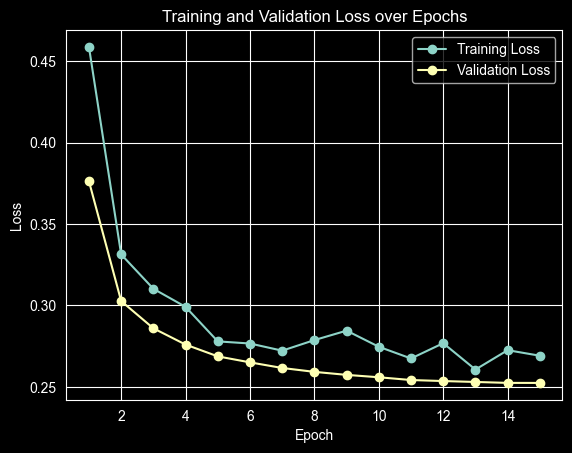

In [20]:
plt.figure()
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, eval_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.show()


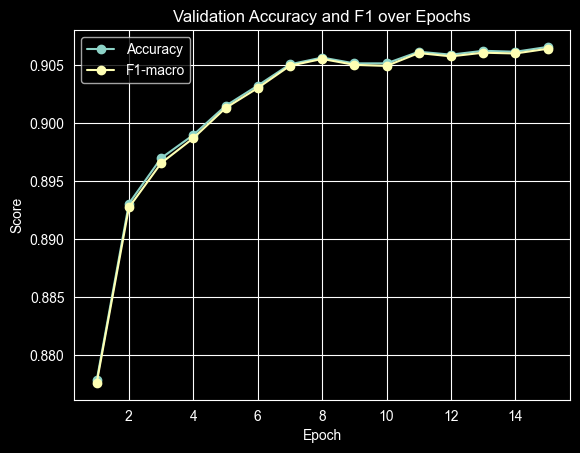

In [21]:
accuracy = []
f1 = []

for log in trainer.state.log_history:
    if "eval_accuracy" in log:
        accuracy.append(log["eval_accuracy"])
        f1.append(log["eval_f1_macro"])

epochs = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, marker='o', label="Accuracy")
plt.plot(epochs, f1, marker='o', label="F1-macro")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 over Epochs")
plt.legend()
plt.show()


In [22]:
# Dự đoán trên toàn bộ validation set
predictions = trainer.predict(tokenized_dataset["validation"])

# predictions là một NamedTuple chứa:
# - predictions.predictions: logits (shape: [12000, 4])
# - predictions.label_ids: nhãn thật (shape: [12000])
# - predictions.metrics: các metric đã tính

print("Metrics từ predict:")
print(predictions.metrics)

# Chuyển logits thành nhãn dự đoán
import numpy as np
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# In ví dụ 10 mẫu đầu
print("\nVí dụ 10 mẫu đầu (true label vs predicted):")
for i in range(10):
    true_text = tokenized_dataset["validation"][i]["text"][:100] + "..."  # cắt ngắn để dễ xem
    print(f"Text: {true_text}")
    print(f"True: {labels[i]} | Pred: {preds[i]}")
    print("-" * 80)

Metrics từ predict:
{'test_loss': 0.2523992955684662, 'test_accuracy': 0.9065833333333333, 'test_f1_macro': 0.9064247488872218, 'test_runtime': 15.5586, 'test_samples_per_second': 771.277, 'test_steps_per_second': 24.102}

Ví dụ 10 mẫu đầu (true label vs predicted):
Text: Orange Unveils 3G Phones in Long-Delayed Launch  LONDON/PARIS (Reuters) - Orange unveiled its  third...
True: 3 | Pred: 3
--------------------------------------------------------------------------------
Text: Rival Technologies Vie for 'Green' Car of Tomorrow  PARIS (Reuters) - Carmakers presented new-age au...
True: 3 | Pred: 3
--------------------------------------------------------------------------------
Text: Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from...
True: 0 | Pred: 0
--------------------------------------------------------------------------------
Text: Canadian Bonds Gain; Rising Oil Prices May Curb Economic Growth Canadian bonds gained on concern tha

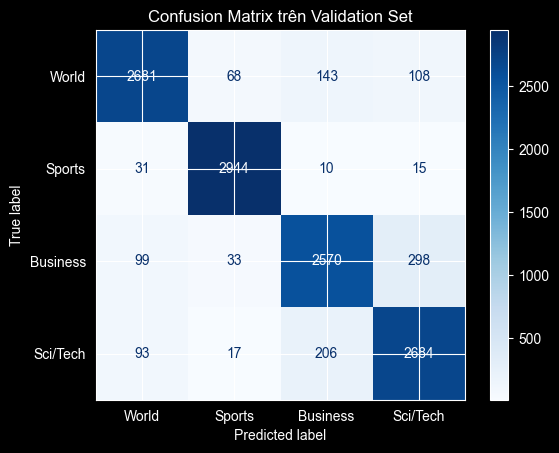

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tính confusion matrix
cm = confusion_matrix(labels, preds)

# Vẽ
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World", "Sports", "Business", "Sci/Tech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix trên Validation Set")
plt.show()